<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week3_dashboard/Week3_Price_Volume_Margin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()  # upload kaggle.json when prompted
os.makedirs('/root/.kaggle', exist_ok=True)

Saving kaggle.json to kaggle.json


In [3]:
kaggle_files = glob.glob('/content/kaggle*.json')
print(f"Found: {kaggle_files}")
!cp "{kaggle_files[0]}" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Found: ['/content/kaggle.json']


In [4]:
!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data

100% 2.70M/2.70M [00:00<00:00, 172MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  


In [5]:
train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

print(f"Data loaded: {df.shape}")
print(df.head(3))

Data loaded: (421570, 16)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  151315  
2         8.106    A  151315  


In [6]:
# We'll use Store 1 across all departments as our base since we know it well from Weeks 1 and 2
store1 = df[df["Store"] == 1].copy()

top_depts = (store1.groupby("Dept")["Weekly_Sales"]
             .sum()
             .sort_values(ascending=False)
             .head(5)
             .index.tolist())

print(f"Top 5 departments by total sales in Store 1: {top_depts}")

store1_top = store1[store1["Dept"].isin(top_depts)].copy()
store1_top = store1_top.sort_values(["Dept", "Date"]).reset_index(drop=True)

print(f"\nRows in working dataset: {store1_top.shape[0]}")
print(f"Date range: {store1_top['Date'].min().date()} to {store1_top['Date'].max().date()}")

Top 5 departments by total sales in Store 1: [92, 95, 90, 38, 93]

Rows in working dataset: 715
Date range: 2010-02-05 to 2012-10-26


In [7]:
def build_pvm_dataset(df_subset, base_price=50, cogs_pct=0.60):
    """
    Build a Price-Volume-Margin dataset from Walmart sales data.

    Assumptions (all documented):
    - Price: derived from normalized sales (inverse relationship)
    - Volume: implied units = weekly_sales / own_price
    - COGS: 60% of price (standard retail gross margin assumption)
    - Gross Margin: (price - cost) * volume
    """
    result = df_subset.copy()

    # Derive price per department (normalize within each dept)
    result["own_price"] = result.groupby("Dept")["Weekly_Sales"].transform(
        lambda x: base_price * (1.2 - 0.4 * (x - x.min()) / (x.max() - x.min() + 1e-9))
    )

    # Derive volume (implied units sold)
    result["volume"] = result["Weekly_Sales"] / result["own_price"]

    # Derive margin components
    result["cost_per_unit"] = result["own_price"] * cogs_pct
    result["gross_margin_per_unit"] = result["own_price"] - result["cost_per_unit"]
    result["total_gross_margin"] = result["gross_margin_per_unit"] * result["volume"]
    result["margin_pct"] = (1 - cogs_pct) * 100  # 40% for all, by assumption

    return result

pvm_df = build_pvm_dataset(store1_top)

print("Documented assumptions:")
print("  Price:  derived from normalized weekly sales (inverse, $40-$60 range)")
print("  Volume: implied units = Weekly_Sales / own_price")
print("  COGS:   60% of price (standard retail gross margin assumption)")
print("  Margin: 40% gross margin (1 - COGS%)\n")

print("PVM dataset summary by department:")
summary = pvm_df.groupby("Dept").agg(
    Avg_Price=("own_price", "mean"),
    Avg_Volume=("volume", "mean"),
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Avg_Gross_Margin=("total_gross_margin", "mean")
).round(2)
print(summary.to_string())

Documented assumptions:
  Price:  derived from normalized weekly sales (inverse, $40-$60 range)
  Volume: implied units = Weekly_Sales / own_price
  COGS:   60% of price (standard retail gross margin assumption)
  Margin: 40% gross margin (1 - COGS%)

PVM dataset summary by department:
      Avg_Price  Avg_Volume  Avg_Weekly_Sales  Avg_Gross_Margin
Dept                                                           
38        53.32     1523.59          79978.22          31991.29
90        53.94     1545.15          82427.55          32971.02
92        53.40     2573.49         135458.97          54183.59
93        52.25     1396.92          71699.18          28679.67
95        50.11     2438.35         120772.06          48308.82


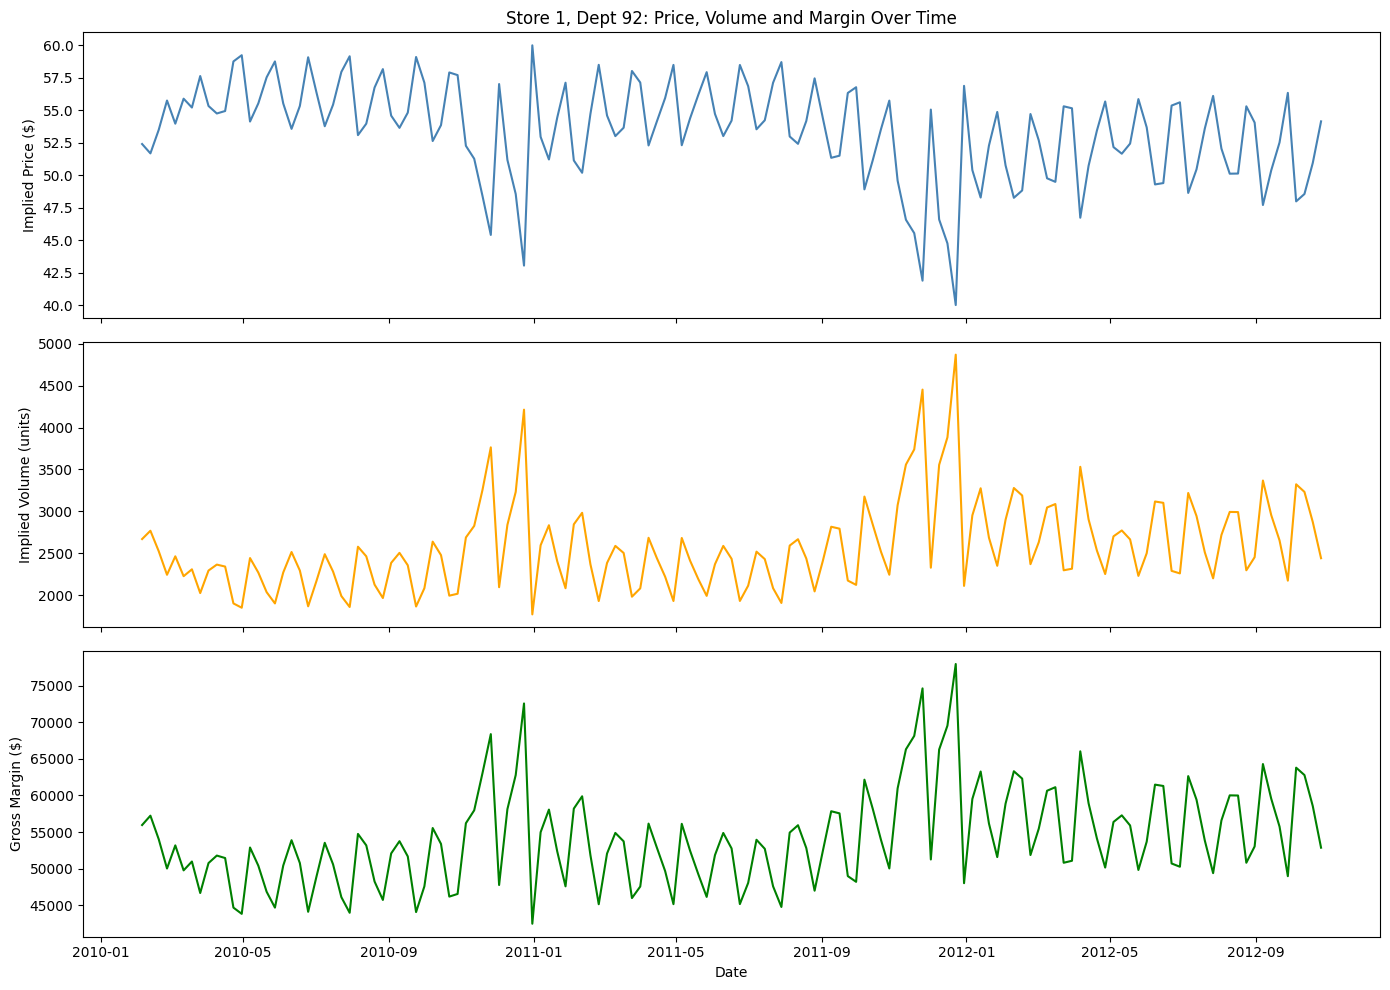

In [8]:
# Use the highest sales department as the showcase
top_dept = top_depts[0]
dept_data = pvm_df[pvm_df["Dept"] == top_dept].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dept_data["Date"], dept_data["own_price"],
             color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Implied Price ($)")
axes[0].set_title(f"Store 1, Dept {top_dept}: Price, Volume and Margin Over Time")

axes[1].plot(dept_data["Date"], dept_data["volume"],
             color="orange", linewidth=1.5)
axes[1].set_ylabel("Implied Volume (units)")

axes[2].plot(dept_data["Date"], dept_data["total_gross_margin"],
             color="green", linewidth=1.5)
axes[2].set_ylabel("Gross Margin ($)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("week3_day11_pvm_base.png", dpi=150)
plt.show()

In [9]:
# We test a range of elasticity assumptions since we can't calculate true elasticity from this dataset
elasticity_scenarios = {
    "Inelastic (-0.5)":       -0.5,
    "Moderate (-1.0)":        -1.0,
    "Standard (-1.5)":        -1.5,
    "Elastic (-2.0)":         -2.0,
    "Highly Elastic (-2.5)":  -2.5
}

# Base case: Dept 92 average price and volume
base_price = pvm_df[pvm_df["Dept"] == 92]["own_price"].mean()
base_volume = pvm_df[pvm_df["Dept"] == 92]["volume"].mean()
cogs_pct = 0.60

print(f"Base case (Dept 92):")
print(f"  Avg price:  ${base_price:.2f}")
print(f"  Avg volume: {base_volume:.0f} units/week")
print(f"  COGS:       {cogs_pct:.0%}")
print(f"  Base margin: ${base_price * (1 - cogs_pct) * base_volume:,.0f}/week\n")

# Simulate price changes from -20% to +20% in 5% steps
price_changes = [-0.20, -0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15, 0.20]

rows = []
for scenario, elasticity in elasticity_scenarios.items():
    for pct_change in price_changes:
        new_price = base_price * (1 + pct_change)
        new_volume = base_volume * (1 + elasticity * pct_change)
        new_volume = max(new_volume, 0)
        new_revenue = new_price * new_volume
        new_margin = new_price * (1 - cogs_pct) * new_volume
        rows.append({
            "Scenario": scenario,
            "Elasticity": elasticity,
            "Price_Change_Pct": pct_change * 100,
            "New_Price": new_price,
            "New_Volume": new_volume,
            "New_Revenue": new_revenue,
            "New_Margin": new_margin,
            "Margin_vs_Base": new_margin - (base_price * (1 - cogs_pct) * base_volume)
        })

elasticity_df = pd.DataFrame(rows)
print("Sample output (Standard elasticity -1.5):")
print(elasticity_df[elasticity_df["Scenario"] == "Standard (-1.5)"][
    ["Price_Change_Pct", "New_Price", "New_Volume", "New_Revenue", "New_Margin"]
].round(2).to_string(index=False))

Base case (Dept 92):
  Avg price:  $53.40
  Avg volume: 2573 units/week
  COGS:       60%
  Base margin: $54,969/week

Sample output (Standard elasticity -1.5):
 Price_Change_Pct  New_Price  New_Volume  New_Revenue  New_Margin
            -20.0      42.72     3345.54    142918.83    57167.53
            -15.0      45.39     3152.53    143090.61    57236.24
            -10.0      48.06     2959.51    142231.72    56892.69
             -5.0      50.73     2766.50    140342.17    56136.87
              0.0      53.40     2573.49    137421.95    54968.78
              5.0      56.07     2380.48    133471.07    53388.43
             10.0      58.74     2187.47    128489.52    51395.81
             15.0      61.41     1994.45    122477.31    48990.93
             20.0      64.08     1801.44    115434.44    46173.78


In [10]:
optimal_prices = []

for scenario, elasticity in elasticity_scenarios.items():
    scenario_df = elasticity_df[elasticity_df["Scenario"] == scenario]
    best_row = scenario_df.loc[scenario_df["New_Margin"].idxmax()]
    optimal_prices.append({
        "Scenario": scenario,
        "Elasticity": elasticity,
        "Optimal_Price_Change": best_row["Price_Change_Pct"],
        "Optimal_Price": best_row["New_Price"],
        "Optimal_Margin": best_row["New_Margin"],
        "Margin_vs_Base": best_row["Margin_vs_Base"]
    })

optimal_df = pd.DataFrame(optimal_prices)
print("Optimal price point by elasticity scenario:")
print(optimal_df[["Scenario", "Optimal_Price_Change",
                   "Optimal_Price", "Optimal_Margin",
                   "Margin_vs_Base"]].round(2).to_string(index=False))

Optimal price point by elasticity scenario:
             Scenario  Optimal_Price_Change  Optimal_Price  Optimal_Margin  Margin_vs_Base
     Inelastic (-0.5)                  20.0          64.08        59366.28         4397.50
      Moderate (-1.0)                   0.0          53.40        54968.78            0.00
      Standard (-1.5)                 -15.0          45.39        57236.24         2267.46
       Elastic (-2.0)                 -20.0          42.72        61565.03         6596.25
Highly Elastic (-2.5)                 -20.0          42.72        65962.54        10993.76


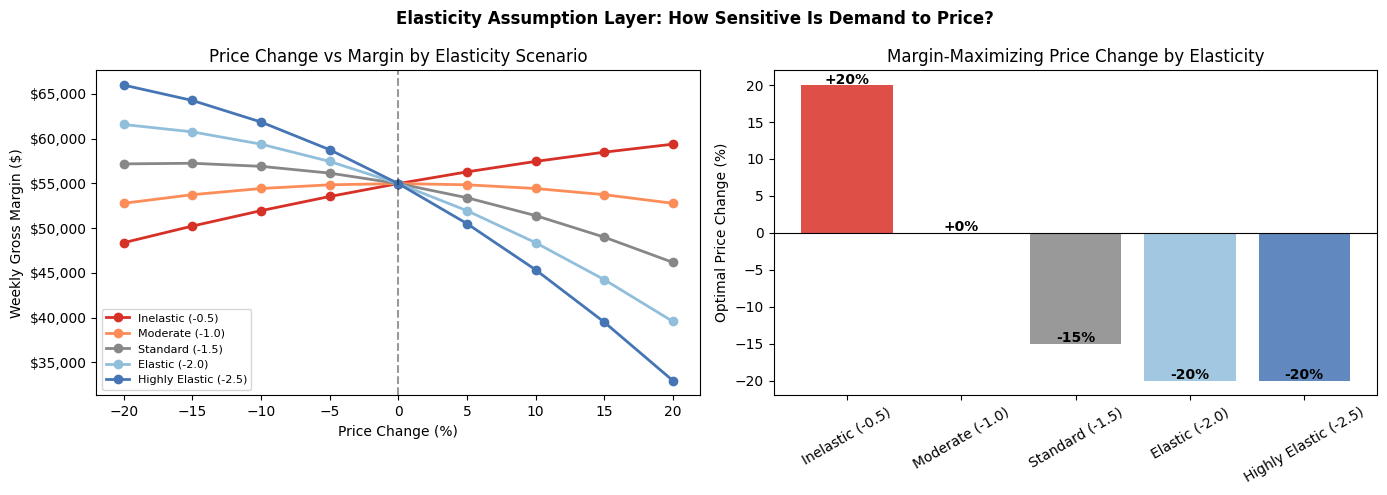

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#d73027", "#fc8d59", "#878787", "#91bfdb", "#4575b4"]

# Left: price change vs margin under different elasticity assumptions
for (scenario, elasticity), color in zip(elasticity_scenarios.items(), colors):
    subset = elasticity_df[elasticity_df["Scenario"] == scenario]
    axes[0].plot(subset["Price_Change_Pct"], subset["New_Margin"],
                 marker="o", label=scenario, color=color, linewidth=2)

axes[0].axvline(x=0, color="black", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Price Change (%)")
axes[0].set_ylabel("Weekly Gross Margin ($)")
axes[0].set_title("Price Change vs Margin by Elasticity Scenario")
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))

# Right: optimal price change per scenario
bars = axes[1].bar(optimal_df["Scenario"],
                   optimal_df["Optimal_Price_Change"],
                   color=colors, alpha=0.85)
axes[1].set_ylabel("Optimal Price Change (%)")
axes[1].set_title("Margin-Maximizing Price Change by Elasticity")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(y=0, color="black", linewidth=0.8)
for bar, val in zip(bars, optimal_df["Optimal_Price_Change"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val:+.0f}%", ha="center", fontweight="bold")

plt.suptitle("Elasticity Assumption Layer: How Sensitive Is Demand to Price?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("week3_day12_elasticity.png", dpi=150)
plt.show()

In [12]:
# Current "baseline" from most recent 4 weeks of data
dept92 = pvm_df[pvm_df["Dept"] == 92].sort_values("Date").tail(4)
current_price = dept92["own_price"].mean()
current_volume = dept92["volume"].mean()
current_margin = dept92["total_gross_margin"].mean()

print("Current baseline (last 4 weeks, Dept 92):")
print(f"  Price:  ${current_price:.2f}")
print(f"  Volume: {current_volume:.0f} units/week")
print(f"  Margin: ${current_margin:,.0f}/week")

# Build scenario matrix: 3 elasticity assumptions x 9 price points
dashboard_scenarios = {
    "Conservative (-1.0)": -1.0,
    "Base Case (-1.5)":    -1.5,
    "Aggressive (-2.0)":   -2.0
}

price_changes = np.arange(-0.20, 0.25, 0.05)
dashboard_rows = []

for scenario, elasticity in dashboard_scenarios.items():
    for pct_change in price_changes:
        new_price = current_price * (1 + pct_change)
        new_volume = current_volume * (1 + elasticity * pct_change)
        new_volume = max(new_volume, 0)
        new_margin = new_price * (1 - cogs_pct) * new_volume
        dashboard_rows.append({
            "Scenario": scenario,
            "Price_Change_Pct": round(pct_change * 100, 1),
            "New_Price": new_price,
            "New_Volume": new_volume,
            "New_Margin": new_margin,
            "Revenue": new_price * new_volume
        })

dashboard_df = pd.DataFrame(dashboard_rows)
print(f"\nDashboard scenarios built: {len(dashboard_df)} rows")
print(f"Price range: ${dashboard_df['New_Price'].min():.2f} to ${dashboard_df['New_Price'].max():.2f}")

Current baseline (last 4 weeks, Dept 92):
  Price:  $50.40
  Volume: 2968 units/week
  Margin: $59,495/week

Dashboard scenarios built: 27 rows
Price range: $40.32 to $60.48


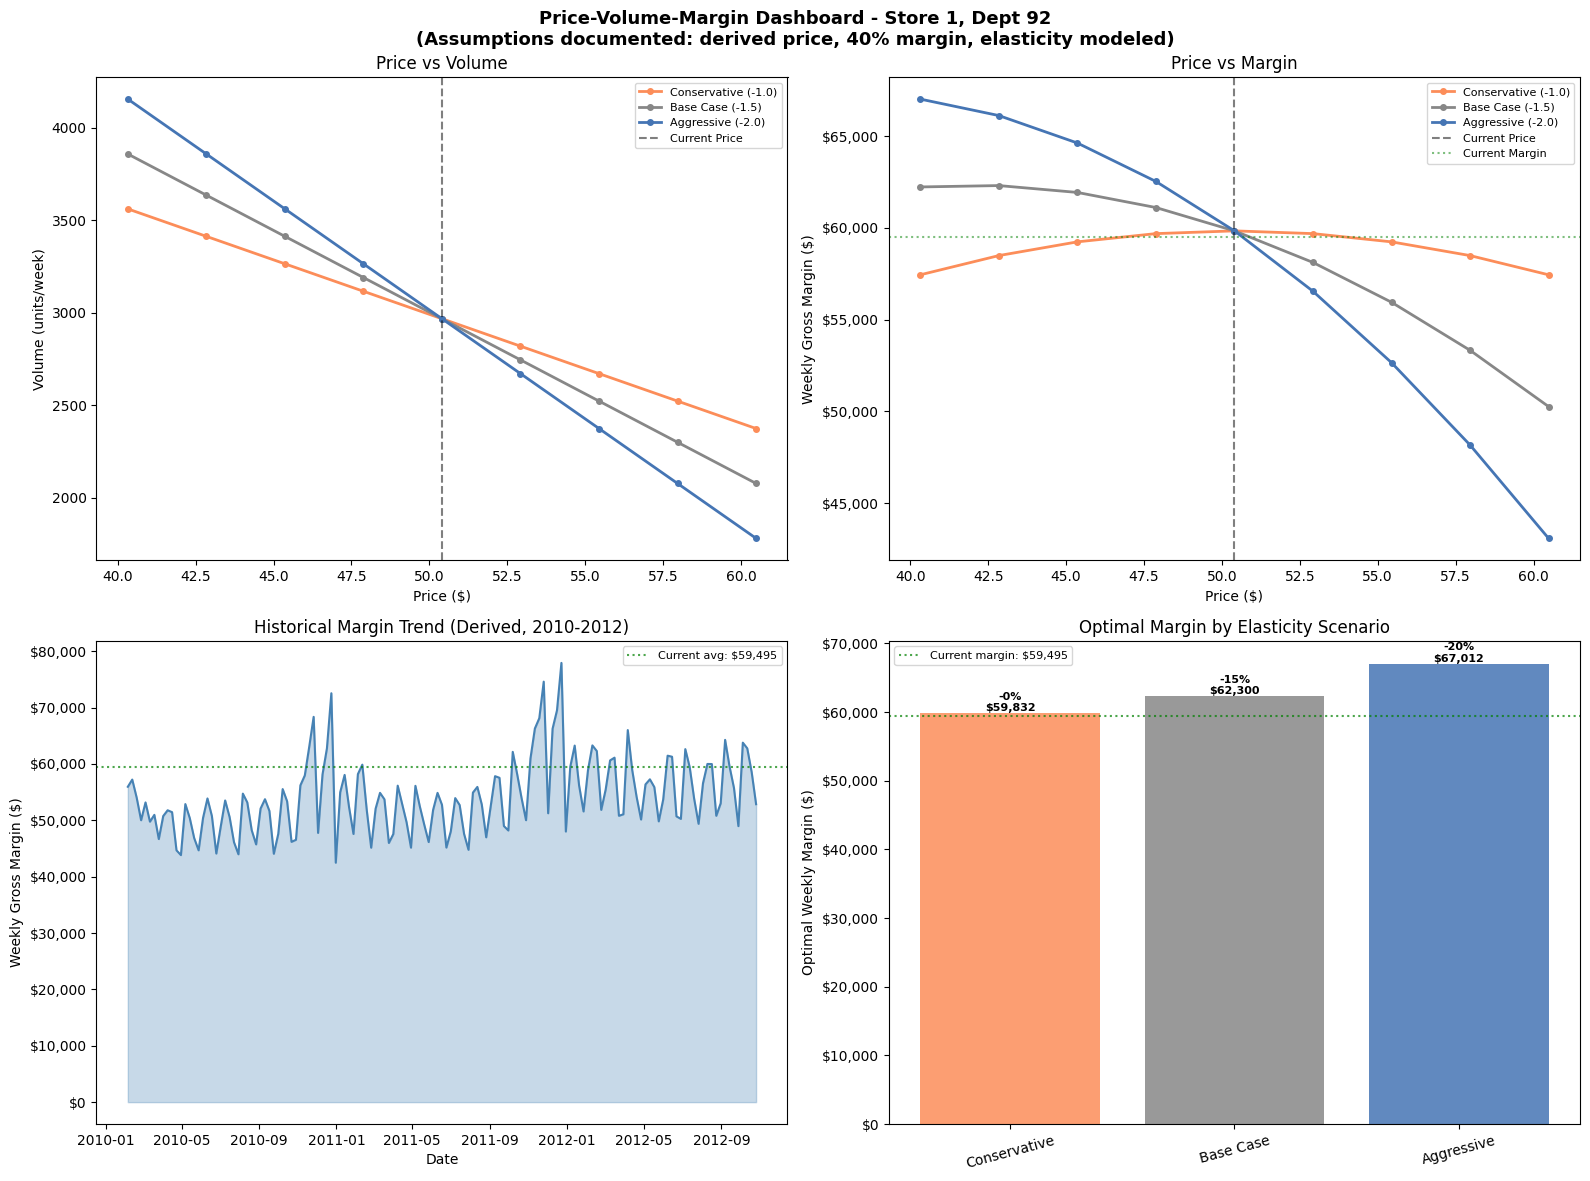

In [13]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Price-Volume-Margin Dashboard - Store 1, Dept 92\n(Assumptions documented: derived price, 40% margin, elasticity modeled)",
             fontsize=13, fontweight="bold", y=0.98)

colors = {"Conservative (-1.0)": "#fc8d59",
          "Base Case (-1.5)":    "#878787",
          "Aggressive (-2.0)":   "#4575b4"}

# ----- Panel 1: Price vs Volume -----
ax1 = fig.add_subplot(2, 2, 1)
for scenario, color in colors.items():
    subset = dashboard_df[dashboard_df["Scenario"] == scenario]
    ax1.plot(subset["New_Price"], subset["New_Volume"],
             marker="o", color=color, label=scenario, linewidth=2, markersize=4)
ax1.axvline(x=current_price, color="black", linestyle="--", alpha=0.5, label="Current Price")
ax1.set_xlabel("Price ($)")
ax1.set_ylabel("Volume (units/week)")
ax1.set_title("Price vs Volume")
ax1.legend(fontsize=8)

# ----- Panel 2: Price vs Margin -----
ax2 = fig.add_subplot(2, 2, 2)
for scenario, color in colors.items():
    subset = dashboard_df[dashboard_df["Scenario"] == scenario]
    ax2.plot(subset["New_Price"], subset["New_Margin"],
             marker="o", color=color, label=scenario, linewidth=2, markersize=4)
ax2.axvline(x=current_price, color="black", linestyle="--", alpha=0.5, label="Current Price")
ax2.axhline(y=current_margin, color="green", linestyle=":", alpha=0.5, label="Current Margin")
ax2.set_xlabel("Price ($)")
ax2.set_ylabel("Weekly Gross Margin ($)")
ax2.set_title("Price vs Margin")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
ax2.legend(fontsize=8)

# ----- Panel 3: Historical margin trend (real data) -----
ax3 = fig.add_subplot(2, 2, 3)
dept92_full = pvm_df[pvm_df["Dept"] == 92].sort_values("Date")
ax3.fill_between(dept92_full["Date"], dept92_full["total_gross_margin"],
                 alpha=0.3, color="steelblue")
ax3.plot(dept92_full["Date"], dept92_full["total_gross_margin"],
         color="steelblue", linewidth=1.5)
ax3.axhline(y=current_margin, color="green", linestyle=":",
            alpha=0.7, label=f"Current avg: ${current_margin:,.0f}")
ax3.set_xlabel("Date")
ax3.set_ylabel("Weekly Gross Margin ($)")
ax3.set_title("Historical Margin Trend (Derived, 2010-2012)")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
ax3.legend(fontsize=8)

# ----- Panel 4: Optimal price recommendation summary -----
ax4 = fig.add_subplot(2, 2, 4)
optimal_summary = []
for scenario, elasticity in dashboard_scenarios.items():
    subset = dashboard_df[dashboard_df["Scenario"] == scenario]
    best = subset.loc[subset["New_Margin"].idxmax()]
    optimal_summary.append({
        "Scenario": scenario.split("(")[0].strip(),
        "Optimal_Price": best["New_Price"],
        "Optimal_Margin": best["New_Margin"],
        "Price_Change": best["Price_Change_Pct"]
    })

opt_sum_df = pd.DataFrame(optimal_summary)
bar_colors = [colors[s] for s in dashboard_scenarios.keys()]
bars = ax4.bar(opt_sum_df["Scenario"], opt_sum_df["Optimal_Margin"],
               color=bar_colors, alpha=0.85)
ax4.axhline(y=current_margin, color="green", linestyle=":",
            alpha=0.7, label=f"Current margin: ${current_margin:,.0f}")
ax4.set_ylabel("Optimal Weekly Margin ($)")
ax4.set_title("Optimal Margin by Elasticity Scenario")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
ax4.tick_params(axis="x", rotation=15)
ax4.legend(fontsize=8)
for bar, row in zip(bars, opt_sum_df.itertuples()):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f"{row.Price_Change:+.0f}%\n${row.Optimal_Margin:,.0f}",
             ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("week3_day13_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("PRICE-VOLUME-MARGIN DASHBOARD SUMMARY")
print("=" * 60)
print(f"Department:     Store 1, Dept 92")
print(f"Current Price:  ${current_price:.2f}")
print(f"Current Volume: {current_volume:.0f} units/week")
print(f"Current Margin: ${current_margin:,.0f}/week")
print(f"COGS Assumption: 60% (40% gross margin)")
print("=" * 60)
print("\nOptimal price recommendation by elasticity scenario:")
print(f"{'Scenario':<25} {'Optimal Price':>15} {'Price Change':>13} {'Weekly Margin':>15}")
print("-" * 70)
for scenario, elasticity in dashboard_scenarios.items():
    subset = dashboard_df[dashboard_df["Scenario"] == scenario]
    best = subset.loc[subset["New_Margin"].idxmax()]
    print(f"{scenario:<25} ${best['New_Price']:>13.2f} "
          f"{best['Price_Change_Pct']:>+12.0f}% "
          f"${best['New_Margin']:>13,.0f}")
print("=" * 60)

PRICE-VOLUME-MARGIN DASHBOARD SUMMARY
Department:     Store 1, Dept 92
Current Price:  $50.40
Current Volume: 2968 units/week
Current Margin: $59,495/week
COGS Assumption: 60% (40% gross margin)

Optimal price recommendation by elasticity scenario:
Scenario                    Optimal Price  Price Change   Weekly Margin
----------------------------------------------------------------------
Conservative (-1.0)       $        50.40           -0% $       59,832
Base Case (-1.5)          $        42.84          -15% $       62,300
Aggressive (-2.0)         $        40.32          -20% $       67,012


In [15]:
scenario_price_change = 0.05  # +5% price increase
new_price = current_price * (1 + scenario_price_change)

print(f"SCENARIO: +5% Price Increase")
print(f"Current price: ${current_price:.2f}")
print(f"New price:     ${new_price:.2f}")
print(f"Price change:  +${new_price - current_price:.2f} per unit\n")

scenario_results = []

for scenario, elasticity in dashboard_scenarios.items():
    new_volume = current_volume * (1 + elasticity * scenario_price_change)
    new_revenue = new_price * new_volume
    new_margin = new_price * (1 - cogs_pct) * new_volume

    volume_change = new_volume - current_volume
    revenue_change = new_revenue - (current_price * current_volume)
    margin_change = new_margin - current_margin

    scenario_results.append({
        "Scenario": scenario,
        "Elasticity": elasticity,
        "New_Price": new_price,
        "New_Volume": new_volume,
        "Volume_Change": volume_change,
        "Volume_Change_Pct": (volume_change / current_volume) * 100,
        "New_Revenue": new_revenue,
        "Revenue_Change": revenue_change,
        "New_Margin": new_margin,
        "Margin_Change": margin_change,
        "Margin_Change_Pct": (margin_change / current_margin) * 100
    })

scenario_df = pd.DataFrame(scenario_results)

print(f"{'Scenario':<25} {'Vol Change':>12} {'Rev Change':>14} {'Margin Change':>15}")
print("-" * 70)
for _, row in scenario_df.iterrows():
    print(f"{row['Scenario']:<25} "
          f"{row['Volume_Change_Pct']:>+10.1f}%  "
          f"${row['Revenue_Change']:>+11,.0f}  "
          f"${row['Margin_Change']:>+12,.0f}")
print(f"\nNote: revenue and margin change measured vs current baseline")

SCENARIO: +5% Price Increase
Current price: $50.40
New price:     $52.92
Price change:  +$2.52 per unit

Scenario                    Vol Change     Rev Change   Margin Change
----------------------------------------------------------------------
Conservative (-1.0)             -5.0%  $       -374  $        +188
Base Case (-1.5)                -7.5%  $     -4,300  $      -1,383
Aggressive (-2.0)              -10.0%  $     -8,227  $      -2,954

Note: revenue and margin change measured vs current baseline


In [16]:
sensitivity_changes = [-0.10, -0.05, 0.00, 0.05, 0.10, 0.15]
base_case_elasticity = -1.5  # use base case as the primary view

sensitivity_rows = []
for pct in sensitivity_changes:
    new_p = current_price * (1 + pct)
    new_v = current_volume * (1 + base_case_elasticity * pct)
    new_v = max(new_v, 0)
    new_r = new_p * new_v
    new_m = new_p * (1 - cogs_pct) * new_v
    sensitivity_rows.append({
        "Price_Change": f"{pct*100:+.0f}%",
        "New_Price": new_p,
        "New_Volume": new_v,
        "Volume_Change_Pct": ((new_v - current_volume) / current_volume) * 100,
        "New_Revenue": new_r,
        "Revenue_Change": new_r - (current_price * current_volume),
        "New_Margin": new_m,
        "Margin_Change": new_m - current_margin,
        "Is_Scenario": pct == 0.05
    })

sens_df = pd.DataFrame(sensitivity_rows)

print("Price Sensitivity Table (Base Case elasticity -1.5):")
print(f"{'Price Change':>12} {'New Price':>10} {'Vol Change':>11} {'Rev Change':>13} {'Margin Change':>14}")
print("-" * 65)
for _, row in sens_df.iterrows():
    marker = " <-- +5% scenario" if row["Price_Change"] == "+5%" else ""
    print(f"{row['Price_Change']:>12} "
          f"${row['New_Price']:>8.2f} "
          f"{row['Volume_Change_Pct']:>+9.1f}%  "
          f"${row['Revenue_Change']:>+10,.0f}  "
          f"${row['Margin_Change']:>+11,.0f}{marker}")

Price Sensitivity Table (Base Case elasticity -1.5):
Price Change  New Price  Vol Change    Rev Change  Margin Change
-----------------------------------------------------------------
        -10% $   45.36     +15.0%  $    +5,235  $     +2,431
         -5% $   47.88      +7.5%  $    +3,179  $     +1,609
         +0% $   50.40      +0.0%  $        +0  $       +337
         +5% $   52.92      -7.5%  $    -4,300  $     -1,383 <-- +5% scenario
        +10% $   55.44     -15.0%  $    -9,723  $     -3,552
        +15% $   57.96     -22.5%  $   -16,267  $     -6,170


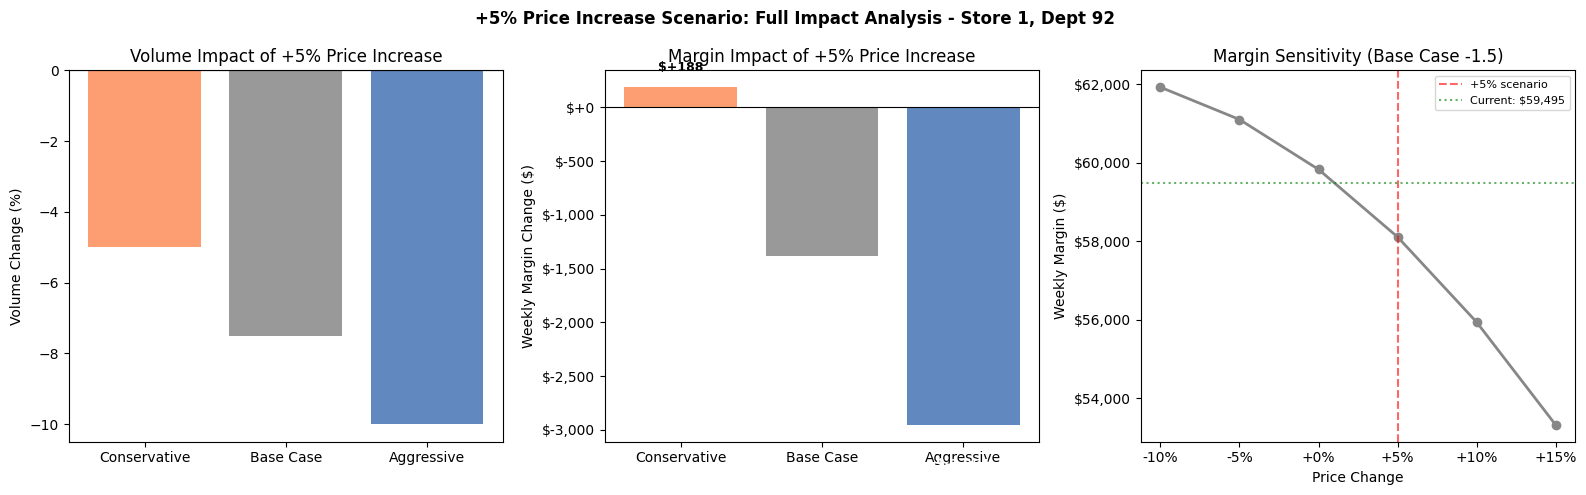

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scenario_labels = [s.split("(")[0].strip() for s in scenario_df["Scenario"]]
bar_colors = ["#fc8d59", "#878787", "#4575b4"]

# Left: volume change by scenario
bars1 = axes[0].bar(scenario_labels, scenario_df["Volume_Change_Pct"],
                    color=bar_colors, alpha=0.85)
axes[0].axhline(y=0, color="black", linewidth=0.8)
axes[0].set_ylabel("Volume Change (%)")
axes[0].set_title("Volume Impact of +5% Price Increase")
for bar, val in zip(bars1, scenario_df["Volume_Change_Pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 0.3,
                 f"{val:+.1f}%", ha="center",
                 fontweight="bold", color="white")

# Middle: margin change by scenario
bars2 = axes[1].bar(scenario_labels, scenario_df["Margin_Change"],
                    color=bar_colors, alpha=0.85)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_ylabel("Weekly Margin Change ($)")
axes[1].set_title("Margin Impact of +5% Price Increase")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:+,.0f}"))
for bar, val in zip(bars2, scenario_df["Margin_Change"]):
    offset = 150 if val >= 0 else -400
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + offset,
                 f"${val:+,.0f}", ha="center",
                 fontsize=9, fontweight="bold",
                 color="white" if val < 0 else "black")

# Right: sensitivity table as line chart (base case)
axes[2].plot(sens_df["Price_Change"], sens_df["New_Margin"],
             marker="o", color="#878787", linewidth=2)
axes[2].axvline(x=3, color="red", linestyle="--",
                alpha=0.6, label="+5% scenario")
axes[2].axhline(y=current_margin, color="green",
                linestyle=":", alpha=0.6, label=f"Current: ${current_margin:,.0f}")
axes[2].set_xlabel("Price Change")
axes[2].set_ylabel("Weekly Margin ($)")
axes[2].set_title("Margin Sensitivity (Base Case -1.5)")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
axes[2].legend(fontsize=8)

plt.suptitle("+5% Price Increase Scenario: Full Impact Analysis - Store 1, Dept 92",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("week3_day14_scenario.png", dpi=150)
plt.show()

In [18]:
print("3-WEEK PRICING ANALYTICS TOOLKIT - FINAL SUMMARY")
print("=" * 60)

print("\nWEEK 1: Competitive Repricing Simulator")
print("-" * 40)
print("  Dataset:      Walmart Store Sales (real) + simulated competitor")
print("  Scope:        10 store/department pairs, 143 weeks each")
print("  V1 engine:    79.9% avg trigger rate (no threshold)")
print("  V2 engine:    41.7% avg trigger rate (10% threshold)")
print("  Reduction:    38.1% fewer unnecessary repricings")
print("  Key insight:  Repricing rules need a minimum gap threshold,")
print("                not just a margin floor")

print("\nWEEK 2: Markdown & Promotion Optimization")
print("-" * 40)
print("  Dataset:      Walmart real markdown event data (MarkDown1-5)")
print("  Scope:        22 peak markdown events, S3-D1")
print("  Lift range:   0.9% (S1-D1) to 31.1% (S3-D1) across depts")
print("  Best ROI:     Low markdown spend - $4.48 per markdown dollar")
print("  Worst ROI:    Very high spend   - $0.63 per markdown dollar")
print("  Strategy win: Optimized timing (week -1) +4.7% vs baseline")
print("  Key insight:  Markdown calendars built around event date")
print("                are optimizing for the wrong week")

print("\nWEEK 3: Price-Volume-Margin Dashboard")
print("-" * 40)
print("  Dataset:      Walmart Store 1, top 5 depts (derived PVM)")
print("  Scope:        Dept 92, $50.40 current price, 2,968 units/week")
print("  +5% scenario: Margin +$188 (conservative) to -$2,954 (aggressive)")
print("  Elasticity gap: $1,571/week margin swing between assumptions")
print("  Annualized:   $80,000+ on one department from one wrong assumption")
print("  Key insight:  Price decisions made without an elasticity view")
print("                are guesses dressed up as strategy")

print("\n" + "=" * 60)
print("GitHub repo: github.com/Snjkmr162/pricing-analytics-toolkit")

3-WEEK PRICING ANALYTICS TOOLKIT - FINAL SUMMARY

WEEK 1: Competitive Repricing Simulator
----------------------------------------
  Dataset:      Walmart Store Sales (real) + simulated competitor
  Scope:        10 store/department pairs, 143 weeks each
  V1 engine:    79.9% avg trigger rate (no threshold)
  V2 engine:    41.7% avg trigger rate (10% threshold)
  Reduction:    38.1% fewer unnecessary repricings
  Key insight:  Repricing rules need a minimum gap threshold,
                not just a margin floor

WEEK 2: Markdown & Promotion Optimization
----------------------------------------
  Dataset:      Walmart real markdown event data (MarkDown1-5)
  Scope:        22 peak markdown events, S3-D1
  Lift range:   0.9% (S1-D1) to 31.1% (S3-D1) across depts
  Best ROI:     Low markdown spend - $4.48 per markdown dollar
  Worst ROI:    Very high spend   - $0.63 per markdown dollar
  Strategy win: Optimized timing (week -1) +4.7% vs baseline
  Key insight:  Markdown calendars built aro

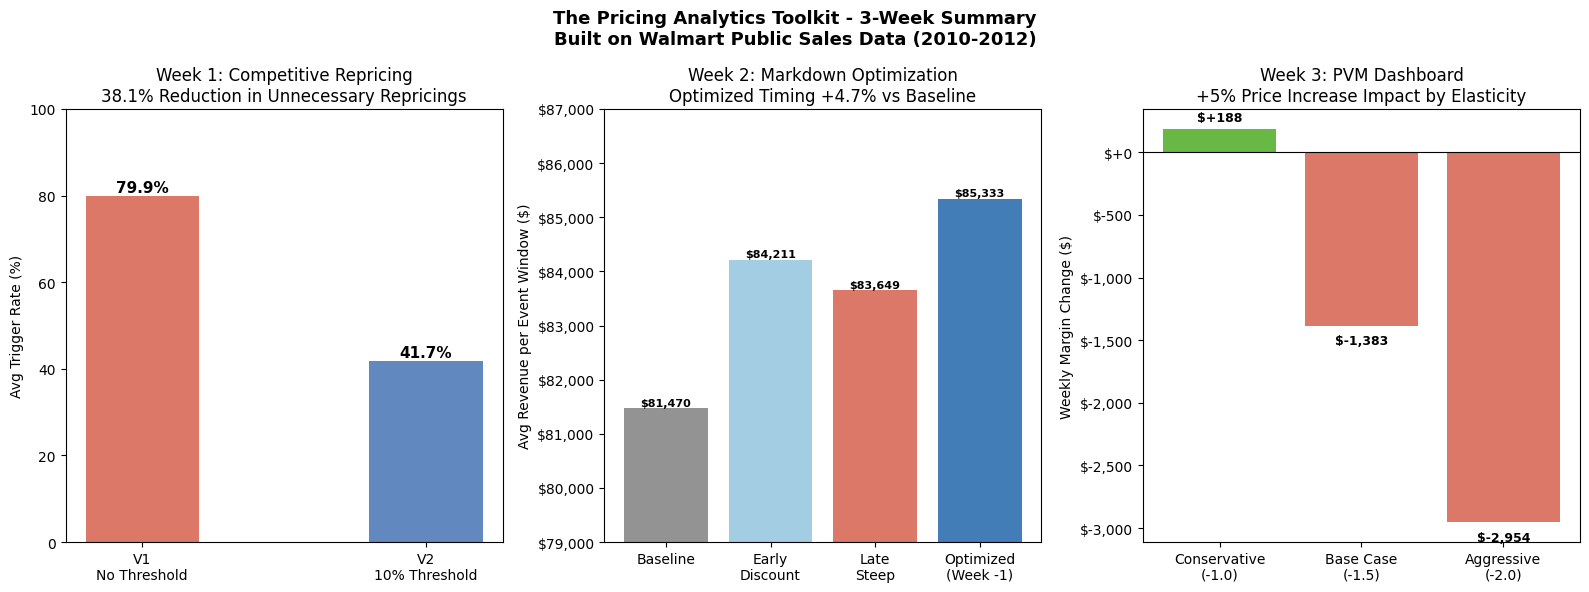

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("The Pricing Analytics Toolkit - 3-Week Summary\nBuilt on Walmart Public Sales Data (2010-2012)",
             fontsize=13, fontweight="bold")

# ----- Week 1: V1 vs V2 trigger rate -----
w1_labels = ["V1\nNo Threshold", "V2\n10% Threshold"]
w1_values = [79.9, 41.7]
w1_colors = ["#d6604d", "#4575b4"]
bars1 = axes[0].bar(w1_labels, w1_values, color=w1_colors, alpha=0.85, width=0.4)
axes[0].set_ylabel("Avg Trigger Rate (%)")
axes[0].set_title("Week 1: Competitive Repricing\n38.1% Reduction in Unnecessary Repricings")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, w1_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val}%", ha="center", fontweight="bold", fontsize=11)

# ----- Week 2: Strategy comparison -----
w2_labels = ["Baseline", "Early\nDiscount", "Late\nSteep", "Optimized\n(Week -1)"]
w2_values = [81470, 84211, 83649, 85333]
w2_colors = ["gray", "#92c5de", "#d6604d", "#2166ac"]
bars2 = axes[1].bar(w2_labels, w2_values, color=w2_colors, alpha=0.85)
axes[1].set_ylabel("Avg Revenue per Event Window ($)")
axes[1].set_title("Week 2: Markdown Optimization\nOptimized Timing +4.7% vs Baseline")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:,.0f}"))
axes[1].set_ylim(79000, 87000)
for bar, val in zip(bars2, w2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f"${val:,.0f}", ha="center", fontsize=8, fontweight="bold")

# ----- Week 3: +5% scenario margin impact -----
w3_labels = ["Conservative\n(-1.0)", "Base Case\n(-1.5)", "Aggressive\n(-2.0)"]
w3_values = [188, -1383, -2954]
w3_colors = ["#4dac26", "#d6604d", "#d6604d"]
bars3 = axes[2].bar(w3_labels, w3_values, color=w3_colors, alpha=0.85)
axes[2].axhline(y=0, color="black", linewidth=0.8)
axes[2].set_ylabel("Weekly Margin Change ($)")
axes[2].set_title("Week 3: PVM Dashboard\n+5% Price Increase Impact by Elasticity")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y:+,.0f}"))
for bar, val in zip(bars3, w3_values):
    offset = 60 if val >= 0 else -150
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + offset,
                 f"${val:+,.0f}", ha="center",
                 fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("week3_day15_final_summary.png", dpi=150)
plt.show()